## 1. Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

from src.utils.constants import SUPPORTED_CATEGORIES, SUPPORTED_SUB_CATEGORIES

FINAL_PATH = ROOT / "data" / "final" / "bali_destinations.csv"


# Konfigurasi tampilan
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

## Load Dataset

In [10]:
df = pd.read_csv(FINAL_PATH)

print("=" * 50)
print("INFORMASI UMUM DATASET")
print("=" * 50)
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"\nDaftar kolom   :")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

print("\n--- 5 Data Pertama ---")
df.head()

INFORMASI UMUM DATASET
Jumlah baris   : 1443
Jumlah kolom   : 27

Daftar kolom   :
  - destination_id (str)
  - name (str)
  - category_raw (str)
  - category_main (str)
  - detail_category (float64)
  - sub_category (str)
  - description (float64)
  - tags (float64)
  - activity (float64)
  - regency_city (str)
  - district (str)
  - estimated_ticket_price (int64)
  - is_free (bool)
  - price_level (str)
  - rating (float64)
  - review_count (int64)
  - latitude (float64)
  - longitude (float64)
  - maps_url (str)
  - image_url (str)
  - has_coordinates (bool)
  - has_description (bool)
  - data_quality_score (float64)
  - content_text (str)
  - popularity_score (float64)
  - budget_tiers (str)
  - recommendation_eligible (bool)

--- 5 Data Pertama ---


,destination_id,name,category_raw,category_main,detail_category,sub_category,description,tags,activity,regency_city,...,longitude,maps_url,image_url,has_coordinates,has_description,data_quality_score,content_text,popularity_score,budget_tiers,recommendation_eligible
0,DEST-001,Patung Titi Banda,Umum,general,NaN,landmark,NaN,NaN,NaN,Denpasar,...,115.255043,https://www.google.com/maps/place/Patung+Titi+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.65,patung titi banda general landmark denpasar de...,0.656787,"low,medium,high",True
1,DEST-002,Uma.palak.(parkir.2),Rekreasi,recreation,NaN,landmark,NaN,NaN,NaN,Denpasar,...,115.212975,https://www.google.com/maps/place/Uma.palak.%2...,https://lh3.googleusercontent.com/p/AF1QipOS1G...,True,False,0.70,uma palak recreation landmark denpasar denpasa...,0.401062,"low,medium,high",True
2,DEST-003,Tukad Bindu Park,Rekreasi,recreation,NaN,landmark,NaN,NaN,NaN,Denpasar,...,115.235812,https://www.google.com/maps/place/Tukad+Bindu+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,tukad bindu park recreation landmark denpasar ...,0.600304,"low,medium,high",True
3,DEST-004,Pantai Padang Galak,Alam,nature,NaN,beach,NaN,NaN,NaN,Denpasar,...,115.263301,https://www.google.com/maps/place/Pantai+Padan...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,pantai padang galak nature beach denpasar denp...,0.536801,"low,medium,high",True
4,DEST-005,Museum Le Mayeur,Budaya,culture,NaN,museum,NaN,NaN,NaN,Denpasar,...,115.263678,https://www.google.com/maps/place/Museum+Le+Ma...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,museum le mayeur culture museum denpasar denpa...,0.504263,"low,medium,high",True


## Feature Engineering

In [11]:
# Encoding kolom kategorikal dengan Label Encoding
le_category   = LabelEncoder()
le_subcategory = LabelEncoder()
le_price_level = LabelEncoder()
le_regency     = LabelEncoder()

df['category_main_enc']  = le_category.fit_transform(df['category_main'])
df['sub_category_enc']   = le_subcategory.fit_transform(df['sub_category'])
df['price_level_enc']    = le_price_level.fit_transform(df['price_level'])
df['regency_city_enc']   = le_regency.fit_transform(df['regency_city'])

print("\nMapping category_main  :", dict(zip(le_category.classes_, le_category.transform(le_category.classes_))))
print("Mapping price_level    :", dict(zip(le_price_level.classes_, le_price_level.transform(le_price_level.classes_))))

# Pilih fitur untuk clustering
features = [
    'rating',
    'review_count',
    'estimated_ticket_price',
    'category_main_enc',
    'sub_category_enc',
    'price_level_enc',
    'data_quality_score'
]

X = df[features].copy()
print(f"\nJumlah fitur untuk clustering : {X.shape[1]}")
print(f"Jumlah sampel                 : {X.shape[0]}")
print("\nFitur yang digunakan:")
for f in features:
    print(f"  - {f}")


Mapping category_main  : {'culture': np.int64(0), 'general': np.int64(1), 'nature': np.int64(2), 'recreation': np.int64(3)}
Mapping price_level    : {'free': np.int64(0), 'high': np.int64(1), 'low': np.int64(2), 'medium': np.int64(3)}

Jumlah fitur untuk clustering : 7
Jumlah sampel                 : 1443

Fitur yang digunakan:
  - rating
  - review_count
  - estimated_ticket_price
  - category_main_enc
  - sub_category_enc
  - price_level_enc
  - data_quality_score


## Normalization

In [12]:
# Menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Determination of Optimal K Value

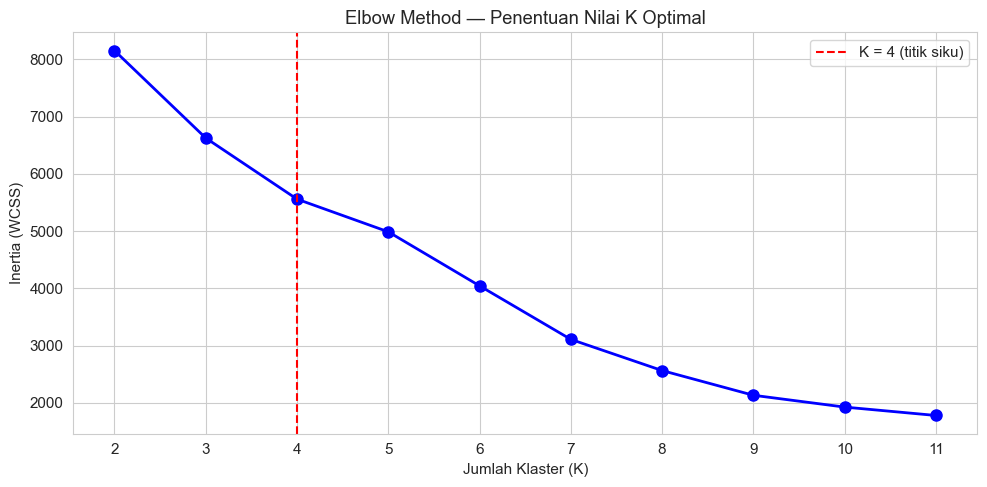

Plot disimpan: elbow_method.png


In [ ]:
# ============================================================
# METODE 1: ELBOW METHOD (Inertia / WCSS)
# ============================================================


k_range = range(2, 12)
inertia_list = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia_list, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Penentuan Nilai K Optimal')
plt.xticks(k_range)
plt.axvline(x=4, color='red', linestyle='--', label='K = 4 (titik siku)')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()
print("Plot disimpan: elbow_method.png")

K =  2 | Silhouette Score = 0.2682
K =  3 | Silhouette Score = 0.3306
K =  4 | Silhouette Score = 0.3622
K =  5 | Silhouette Score = 0.3639
K =  6 | Silhouette Score = 0.3783
K =  7 | Silhouette Score = 0.3944
K =  8 | Silhouette Score = 0.4528
K =  9 | Silhouette Score = 0.4969
K = 10 | Silhouette Score = 0.5203
K = 11 | Silhouette Score = 0.5240


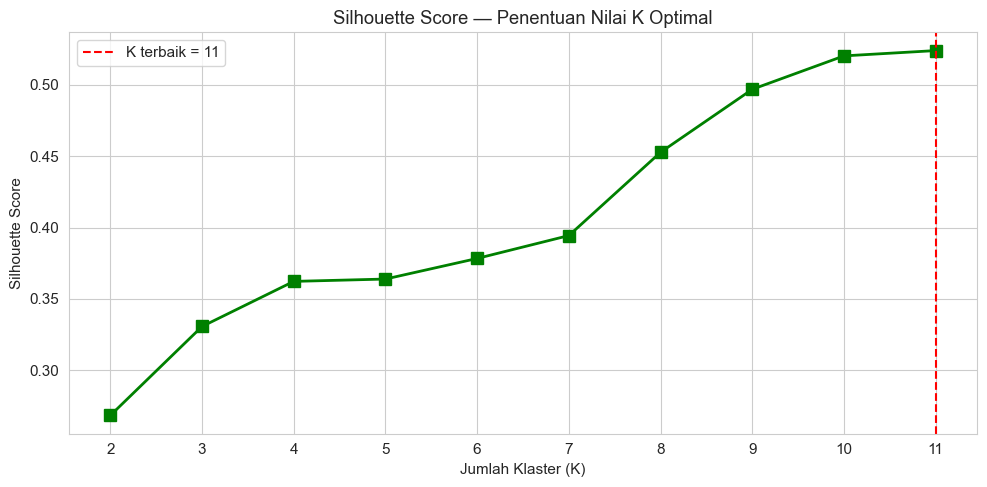


K dengan Silhouette Score tertinggi: 11


In [ ]:
# ============================================================
# METODE 2: SILHOUETTE SCORE
# ============================================================

silhouette_list = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=500, random_state=42)
    silhouette_list.append(score)
    print(f"K = {k:2d} | Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_list, 'gs-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Penentuan Nilai K Optimal')
plt.xticks(k_range)
best_k_sil = k_range[np.argmax(silhouette_list)]
plt.axvline(x=best_k_sil, color='red', linestyle='--', label=f'K terbaik = {best_k_sil}')
plt.legend()
plt.tight_layout()
plt.savefig('silhouette_score.png', dpi=150)
plt.show()
print(f"\nK dengan Silhouette Score tertinggi: {best_k_sil}")

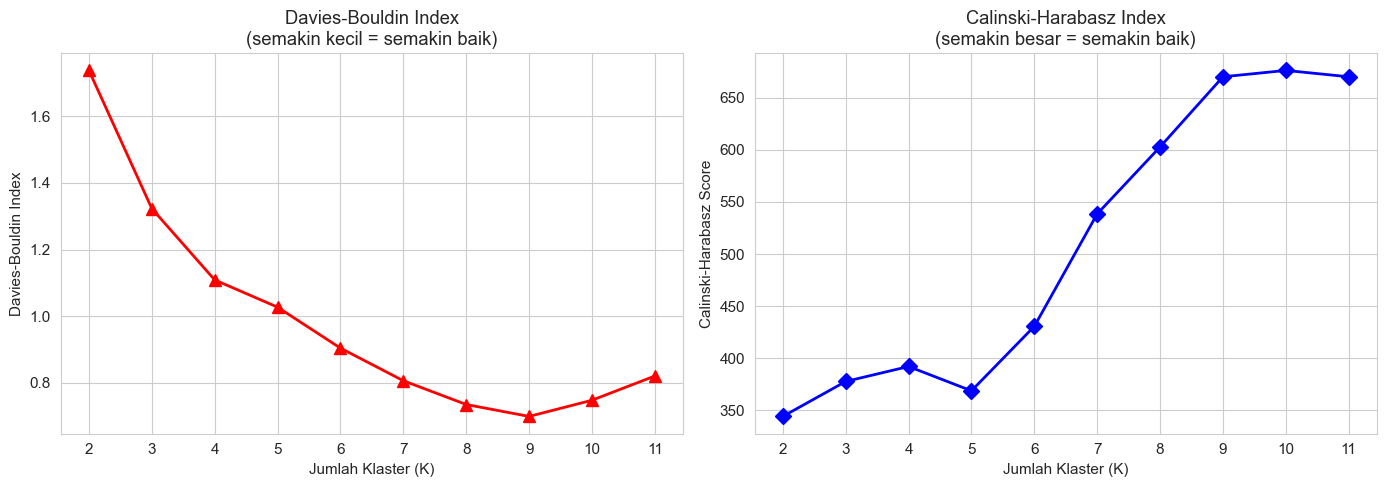


Ringkasan Evaluasi Pemilihan K:
   K |   Silhouette |  Davies-Bouldin |  Calinski-Harabasz
---------------------------------------------------------
   2 |       0.2682 |          1.7381 |             343.99
   3 |       0.3306 |          1.3230 |             377.58
   4 |       0.3622 |          1.1087 |             391.96
   5 |       0.3639 |          1.0269 |             368.59
   6 |       0.3783 |          0.9038 |             430.55
   7 |       0.3944 |          0.8059 |             538.56
   8 |       0.4528 |          0.7345 |             602.91
   9 |       0.4969 |          0.6987 |             670.29
  10 |       0.5203 |          0.7473 |             676.38
  11 |       0.5240 |          0.8201 |             670.29


In [ ]:
# ============================================================
# METODE 3: DAVIES-BOULDIN INDEX & CALINSKI-HARABASZ INDEX
# ============================================================

db_list = []
ch_list = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    db_list.append(davies_bouldin_score(X_scaled, labels))
    ch_list.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, db_list, 'r^-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Klaster (K)')
axes[0].set_ylabel('Davies-Bouldin Index')
axes[0].set_title('Davies-Bouldin Index\n(semakin kecil = semakin baik)')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, ch_list, 'bD-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Klaster (K)')
axes[1].set_ylabel('Calinski-Harabasz Score')
axes[1].set_title('Calinski-Harabasz Index\n(semakin besar = semakin baik)')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.savefig('db_ch_index.png', dpi=150)
plt.show()

print("\nRingkasan Evaluasi Pemilihan K:")
print(f"{'K':>4} | {'Silhouette':>12} | {'Davies-Bouldin':>15} | {'Calinski-Harabasz':>18}")
print("-" * 57)
for i, k in enumerate(k_range):
    print(f"{k:>4} | {silhouette_list[i]:>12.4f} | {db_list[i]:>15.4f} | {ch_list[i]:>18.2f}")